# PHẦN 1 - Thực hiện Canny bằng các thư viện

Mục tiêu: Thực hiện phát hiện cạnh bằng thuật toán Canny trên cùng một ảnh đầu vào bằng hai thư viện OpenCV và Scikit-image.

Tính năng:
- Đọc ảnh đầu vào từ thư mục `input`.
- Chuyển ảnh sang ảnh xám.
- Phát hiện cạnh bằng `cv2.Canny`.
- Phát hiện cạnh bằng `skimage.feature.canny`.
- Đếm số điểm cạnh và đo thời gian xử lý.
- So sánh kết quả giữa hai thư viện.

Đọc ảnh thành công!
Kích thước ảnh: (287, 511, 3)


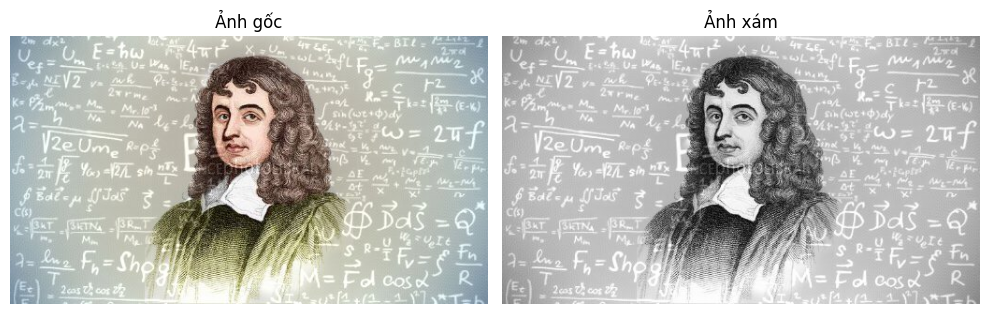

In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature

# Tạo thư mục output nếu chưa có
os.makedirs("../output", exist_ok=True)

# Đọc ảnh trực tiếp từ thư mục input
img_bgr = cv2.imread("../input/demo.jpg")

if img_bgr is None:
    raise FileNotFoundError("Không tìm thấy ảnh tại ../input/demo.jpg")

print("Đọc ảnh thành công!")
print("Kích thước ảnh:", img_bgr.shape)

# Chuyển ảnh sang ánh xám
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

cv2.imwrite("../output/01_gray.png", img_gray)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Ảnh xám")
plt.axis("off")

plt.tight_layout()
plt.show()

## 1. Phát hiện cạnh bằng OpenCV (`cv2.Canny`)

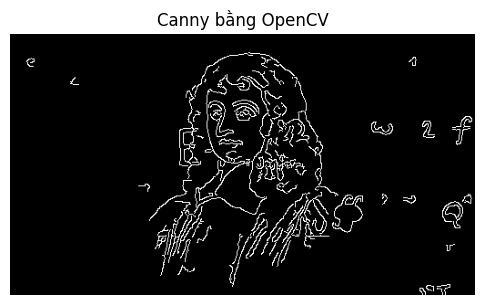

Số pixel cạnh OpenCV: 5843


In [ ]:
sigma = 1.0
low_threshold = 100
high_threshold = 200

# Làm mịn ảnh bằng Gaussian Blur trước khi Canny
kernel_size = int(2 * round(3 * sigma) + 1)

img_blur = cv2.GaussianBlur(
    img_gray,
    (kernel_size, kernel_size),
    sigmaX=sigma,
    sigmaY=sigma
)

# Phát hiện cạnh bằng OpenCV
edges_opencv = cv2.Canny(
    img_blur,
    low_threshold,
    high_threshold
)

cv2.imwrite("../output/02_canny_opencv_default.png", edges_opencv)

plt.figure(figsize=(6, 5))
plt.imshow(edges_opencv, cmap="gray")
plt.title("Canny bằng OpenCV")
plt.axis("off")
plt.show()

print("Số pixel cạnh OpenCV:", np.count_nonzero(edges_opencv > 0))

## 2. Phát hiện cạnh bằng Scikit-image (`skimage.feature.canny`)
Scikit-image tích hợp sẵn bộ lọc Gaussian (mặc định `sigma=1.0`). Kết quả trả về là mảng Boolean (`True` và `False`).

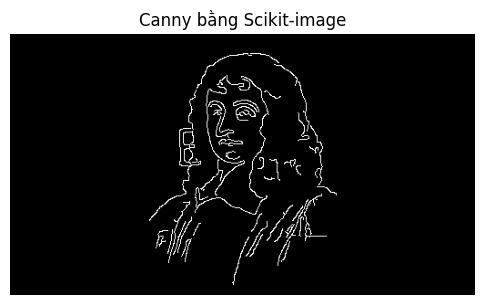

Số pixel cạnh Scikit-image: 3106


In [20]:
# Scikit-image thường xử lý ảnh dạng float từ 0 đến 1
img_gray_float = img_gray.astype(np.float64) / 255.0

# Đổi ngưỡng từ khoảng 0-255 sang 0-1
low = low_threshold / 255.0
high = high_threshold / 255.0

# Phát hiện cạnh bằng Scikit-image
edges_skimage_bool = feature.canny(
    img_gray_float,
    sigma=sigma,
    low_threshold=low,
    high_threshold=high
)

# Chuyển kết quả True/False sang ảnh 0/255 để lưu
edges_skimage = edges_skimage_bool.astype(np.uint8) * 255

cv2.imwrite("../output/03_canny_skimage_default.png", edges_skimage)

plt.figure(figsize=(6, 5))
plt.imshow(edges_skimage, cmap="gray")
plt.title("Canny bằng Scikit-image")
plt.axis("off")
plt.show()

print("Số pixel cạnh Scikit-image:", np.count_nonzero(edges_skimage_bool))

## 3. So sánh trực quan kết quả giữa OpenCV và Scikit-image
Hiển thị ảnh gốc và hai bản đồ cạnh cạnh nhau để nhận xét sự khác biệt.

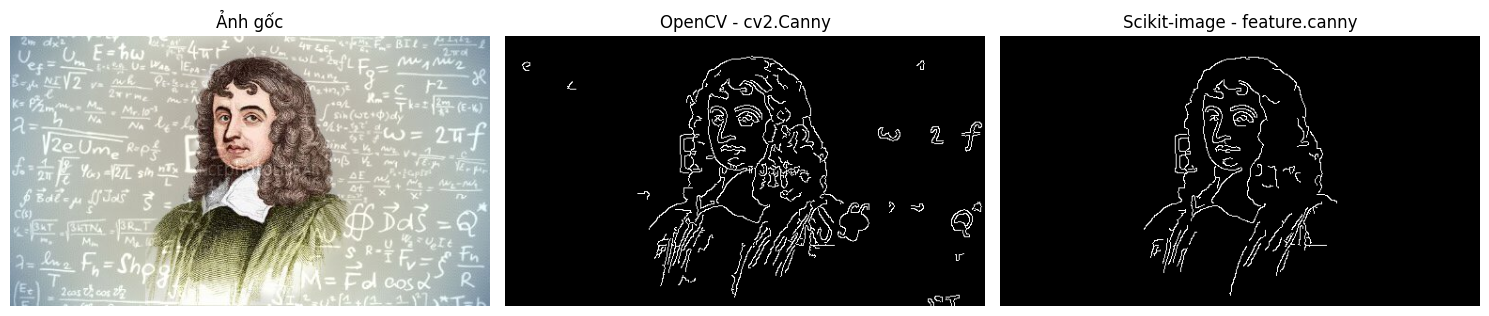

Đã lưu ảnh so sánh tại: ../output/04_compare_opencv_skimage.png


In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edges_opencv, cmap="gray")
plt.title("OpenCV - cv2.Canny")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges_skimage, cmap="gray")
plt.title("Scikit-image - feature.canny")
plt.axis("off")

plt.tight_layout()
plt.savefig("../output/04_compare_opencv_skimage.png", dpi=150)
plt.show()

print("Đã lưu ảnh so sánh tại: ../output/04_compare_opencv_skimage.png")